## Procesamiento de los datos para Machine Learning
Aplicar las técnicas principales de procesamiento de datod para preparar un dataset antes del entrenamiento.


## Parte 1. Comprensión del problema 
Trabajaremos con el Dataset de Titanic, para construir un modelo que sea capaz de predecir si una persona sobrevive o no

In [4]:
import pandas as pd
import numpy as np

#Librerias de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#Librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

#Libreria de Kaggle
import kagglehub

In [5]:
import os

# 1. Descargar el dataset del Titanic desde Kaggle
path = kagglehub.dataset_download("rahulsah06/titanic")
print("El dataset se descargó en:", path)

# 2. Cargar el archivo de entrenamiento (train.csv)
df = pd.read_csv(os.path.join(path, "train.csv"))

# 3. Mostrar las primeras 5 filas para comprobar que todo esté en orden
df.head()

100%|██████████| 34.1k/34.1k [00:00<00:00, 435kB/s]

Extracting files...
El dataset se descargó en: C:\Users\Guadalupe\.cache\kagglehub\datasets\rahulsah06\titanic\versions\1


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Descargamos el Dataset de la pagina Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
path 

'C:\\Users\\Guadalupe\\.cache\\kagglehub\\datasets\\yasserh\\titanic-dataset\\versions\\1'

In [8]:
### Creamos el Dataframe
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [9]:
# Mostramos las primeras 5 filas
dfTitanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
dfTitanic.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

## Parte 2. Seleccion de Variables Predictoras y Variable Objetivo

La variable objetivo sera: Survived

donde 0 = No sobrevivio 1= Sobrevivio

In [13]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [15]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlacion e Hipótesis
vamos a identificar la relación entre variables numericas
Nota: La correlacion No representa la importancia Real de la variable en el modelo


In [18]:
variables_numericas = [
    "Survived",
    "Pclass",
    "SibSp",
    "Parch",
    "Fare"
]

In [19]:
corr = dfTitanic[variables_numericas].corr() #Creamos la matriz de correlacion
corr

,Survived,Pclass,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,0.083081,0.018443,-0.549500
SibSp,-0.035322,0.083081,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.159651,0.216225,1.000000


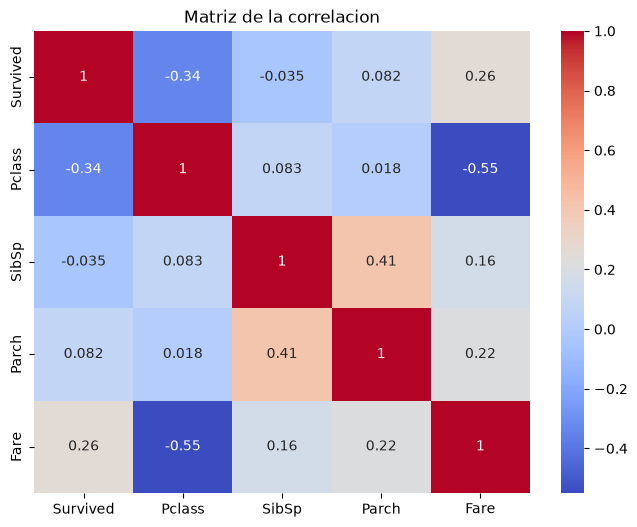

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de la correlacion")
plt.show()

## Parte 4. Variables predictoras.

x---> Aquellas variables que nos ayudan a predecir
y---> Variable objetivo

In [22]:
dfTitanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [23]:
columnas= [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]


In [24]:
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [25]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')

In [26]:
y.name

'Survived'

## Parte 5. limpieza de los datos
Realizaremos la imputación de los datos, donde existan valores nulos

In [28]:
#Revisamos si existen valores nulos
X.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

In [29]:
#vamos a imputar los datos para el campo Edad, calculando la mediana
X["Age"] = X ["Age"].fillna(
    X["Age"].median() 

SyntaxError: incomplete input (2029401204.py, line 3)

In [30]:
#Vamos imputar los datos para el campo Emberked, calculando la moda

X["Embarked"]= X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

C:\Users\Guadalupe\AppData\Local\Temp\ipykernel_16716\3510416700.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"]= X["Embarked"].fillna(


In [31]:
#Revisamos si existen valores nulos
X.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      0
dtype: int64

## Parte 6. Normalizamos los datos categoricos(texto)
Los algoritmos de ML no entienden texto.

In [33]:
X.head(2)

,Pclass,Sex,Age,Fare,Embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C


In [34]:
#One hot Encoding
X = pd.get_dummies(
    X,
    columns=[
        "Sex",
        "Embarked"
    ],
    drop_first= True
)

In [35]:
X.head(2)

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False


## Parte 7. Division de los datos

No debemos entrenar y evaluar utilizando los mismos datos

80% para entrenar

20% para evaluar

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [37]:
print("Entrenamiento X: ", X_train.shape)

Entrenamiento X:  (712, 6)


In [38]:
print("Prueba X: ", X_test.shape)

Prueba X:  (179, 6)


In [39]:
print("Entrenamiento Y: ", y_train.shape)

Entrenamiento Y:  (712,)


In [40]:
print("Prueba y: ", y_test.shape)

Prueba y:  (179,)
